# Visium HD example (bins)

This notebook demonstrates how to visualize Visium HD data.

For Visium HD, because the spots are squares aranged in a grid, we can visualize them as bins. For other untargeted platforms (e.g. Nova-ST, BMK), this is not as straightforward because the bins are hexagons, and we advise to use `hpv.seq_based_from_split_sources`, we refer to [this notebook](./visium_hd_spots.ipynb).

In [1]:
import harpy_vitessce as hpv

In [2]:
import tempfile
from pathlib import Path

tmp_dir = Path(tempfile.mkdtemp(prefix="visium_HD"))

In [3]:
import os

import harpy as hp
import pooch
from harpy.datasets import get_registry
from spatialdata import read_zarr

BASE_DIR = tmp_dir  # change the base directory

# fetch the data
registry = get_registry()
unzip_path = registry.fetch(
    "transcriptomics/visium_hd/mouse/visium_hd_mouse_small_intestine.zip",
    processor=pooch.Unzip(),
)

# path to a visium experiment
path = os.path.commonpath(unzip_path)

# read the downloaded data with harpy.
# when reading visium data with harpy, the table is annotated by a labels element, and the feature matrix .X is a sparse csc matrix.
sdata = hp.io.visium_hd(
    path=path,
    bin_size=[16],
    dataset_id="Visium_HD_Mouse_Small_Intestine",
    output=os.path.join(BASE_DIR, "sdata_visium_hd.zarr"),
)

sdata = read_zarr(os.path.join(BASE_DIR, "sdata_visium_hd.zarr"))

/Users/arne.defauw/VIB/harpy_vitessce/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     The instance_key column in 'table.obs' ('table.obs[location_id]') will be relabeled to ensure a numeric   
         data type, with a continuous range and without including the value 0 (which is reserved for the           
         background). The new labels will be stored in a new column named 'relabeled_location_id'.                 


/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 auto

Run a Scanpy pipeline

2026-06-05 11:59:29.742 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:83 - Starting Scanpy pipeline for Visium HD data.
2026-06-05 11:59:29.799 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:90 - Calculating QC metrics.
2026-06-05 11:59:31.135 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:98 - Filtering cells with min_counts=20.


filtered out 143 cells that have less than 20 counts


2026-06-05 11:59:31.501 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:101 - Filtering genes with min_cells=10.


filtered out 436 genes that are detected in less than 10 cells


2026-06-05 11:59:31.737 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:104 - Shape after filtering: 90890 cells × 18623 genes.
2026-06-05 11:59:31.737 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:107 - Normalizing total counts to None per cell.


...

2026-06-05 12:01:28.354 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:144 - Computing UMAP embedding.


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:39)


2026-06-05 12:02:08.065 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:148 - Running Leiden clustering with resolution=0.8, key_added='leiden'.


running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:04:00)


2026-06-05 12:06:08.822 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:154 - Leiden clustering finished.
2026-06-05 12:06:08.823 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:155 - Number of Leiden clusters: 18
2026-06-05 12:06:08.823 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:158 - Plotting UMAP colored by Leiden clusters.


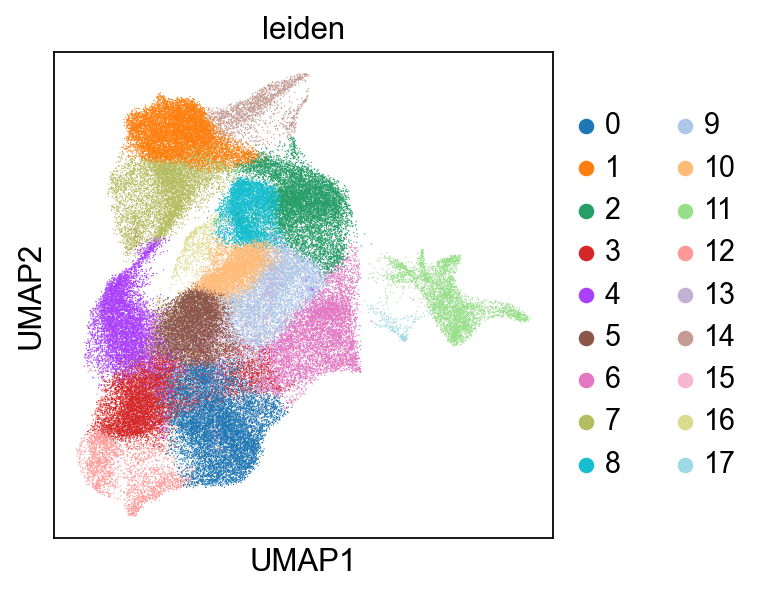

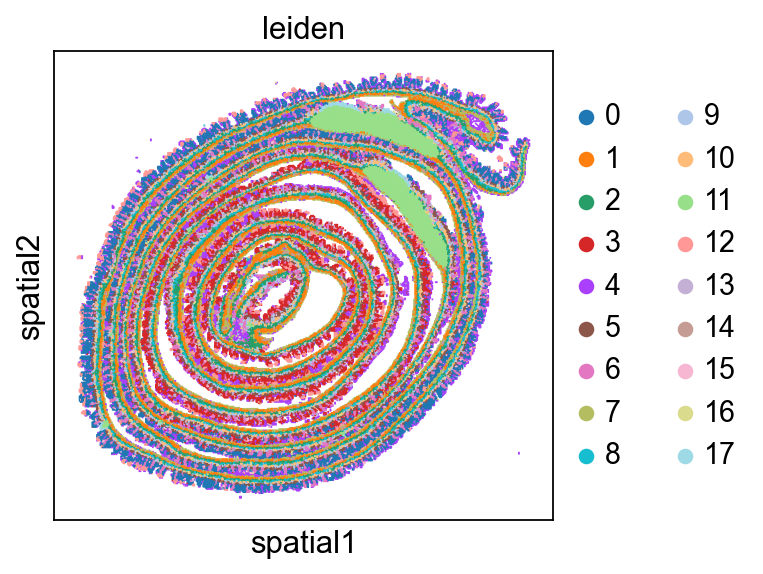

2026-06-05 12:06:12.426 | INFO     | harpy_vitessce.data_utils._visium_hd:example_visium_hd_processing:164 - Scanpy preprocessing and clustering pipeline completed.


In [4]:
from harpy_vitessce.data_utils import (
    copy_annotations,
    downcast_int64_to_int32,
    example_visium_hd_processing,
)

microns_per_pixel = 0.27376126715315274  # microns per pixel

adata = sdata["square_016um"].copy()
# takes around 5 minutes
adata = example_visium_hd_processing(
    adata,
    spatial_spot_size=100,  # for visualization
    min_counts=20,
    target_sum=None,
)

# copy the annotation from the preprocessed adata to the adata with the raw counts (we want to visualize these)

adata_annotated = copy_annotations(
    src=adata,
    tgt=sdata["square_016um"],
    obs_keys=["leiden", "total_counts", "n_genes_by_counts"],
    obsm_keys=["X_umap"],
)
# vitessce can not work with int64
_df, _, _ = downcast_int64_to_int32(
    adata_annotated.obs,
    strict=True,
)
adata_annotated.obs = _df

In [5]:
adata_annotated.obs.head()

,in_tissue,array_row,array_col,fov_labels,cell_ID,leiden,total_counts,n_genes_by_counts
s_016um_00144_00175-1,1,144,175,Visium_HD_Mouse_Small_Intestine_square_016um_l...,1,4,313.0,249
s_016um_00145_00029-1,1,145,29,Visium_HD_Mouse_Small_Intestine_square_016um_l...,2,9,2819.0,1733
s_016um_00165_00109-1,1,165,109,Visium_HD_Mouse_Small_Intestine_square_016um_l...,3,9,2615.0,1644
s_016um_00297_00147-1,1,297,147,Visium_HD_Mouse_Small_Intestine_square_016um_l...,4,13,2860.0,1419
s_016um_00287_00091-1,1,287,91,Visium_HD_Mouse_Small_Intestine_square_016um_l...,5,5,2854.0,1731


#### Write the AnnData table to Zarr

In [7]:
from spatialdata.models import TableModel

# Because we needed to use the AnnDataWrapper to add quality control metrics, we need to make sure the index of the AnnData table matches ID's in the spatial element representing the bins:
adata_annotated.obs.index = adata_annotated.obs["cell_ID"].values

# and back to zarr:
sdata = hp.tb.add_table(
    sdata,
    adata=adata_annotated.copy(),
    region=adata_annotated.uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY],
    output_table_name="square_016um_annotated",
    overwrite=True,
)

/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/contextlib.py:141: UserWarning: zarr v3 auto

#### Add a micron coordinate system.

In [8]:
from spatialdata.transformations import (
    Scale,
    Sequence,
    get_transformation,
    set_transformation,
)

microns_per_pixel = 0.27376126715315274

# add a micron coordinate system to the H&E and to the labels layer representing the bins
to_coordinate_system = "Visium_HD_Mouse_Small_Intestine"

for _name in [
    "Visium_HD_Mouse_Small_Intestine_square_016um_labels",  # labels layer with the bins
    "Visium_HD_Mouse_Small_Intestine_full_image",  # H&E
]:
    transformations = get_transformation(sdata[_name], get_all=True)
    t = transformations[to_coordinate_system]

    scale = Scale(
        scale=[microns_per_pixel, microns_per_pixel], axes=("x", "y")
    )  # add extra scaling to go to microns
    t = Sequence([t, scale])

    set_transformation(
        sdata[_name],
        transformation=t,
        set_all=False,
        to_coordinate_system=f"{to_coordinate_system}_micron",
        write_to_sdata=sdata,
    )

#### Create Vitessce config

In [9]:
from IPython.display import HTML, display

vc = hpv.seq_based_from_spatialdata(
    sdata_path=sdata.path,
    image_name="Visium_HD_Mouse_Small_Intestine_full_image",
    table_name="square_016um_annotated",  # make sure index matches ID's in labels layer if you want to visualize qc metrics.
    labels_name="Visium_HD_Mouse_Small_Intestine_square_016um_labels",
    to_coordinate_system="Visium_HD_Mouse_Small_Intestine_micron",  # plot in microns
    cluster_key="leiden",
    cluster_key_display_name="Leiden",
    qc_obs_feature_keys=["total_counts", "n_genes_by_counts"],
    embedding_key="X_umap",
    embedding_display_name="UMAP",
)

url = vc.web_app()
display(HTML(f'<a href="{url}" target="_blank">Open in Vitessce</a>'))

2026-06-05 12:11:17.391 | WARNING  | harpy_vitessce.vitessce_config._utils:_validate_camera:28 - zoom was provided without center. Vitessce ignores zoom unless center is also set.
